In [1]:
# Plot population at a gridscale point

In [4]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import land_filter
from utils.utils import autosize_figure

In [5]:
# === Path config ===
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/population/"

In [7]:
def plot_population(da, year):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    cmap = plt.get_cmap('GnBu')

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    levels = [0, 1, 25, 100, 250, 1000, 5000, 100000, 1e6]

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = da.plot(
        transform=crs,
        add_colorbar=False,
        cmap=cmap,
        levels=levels,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"SSP2 Population Projection {year}", fontsize=16)

    # First colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("Population", fontsize=13)
    col_bar.set_ticklabels([f"{int(t):,}" for t in levels])

    plt.tight_layout()

    out_file = f"SSP2_population_projection_{year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

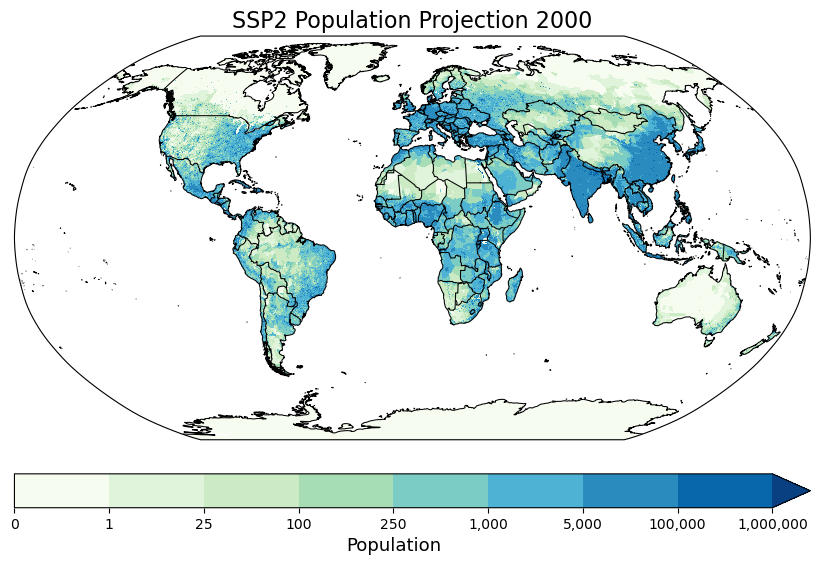

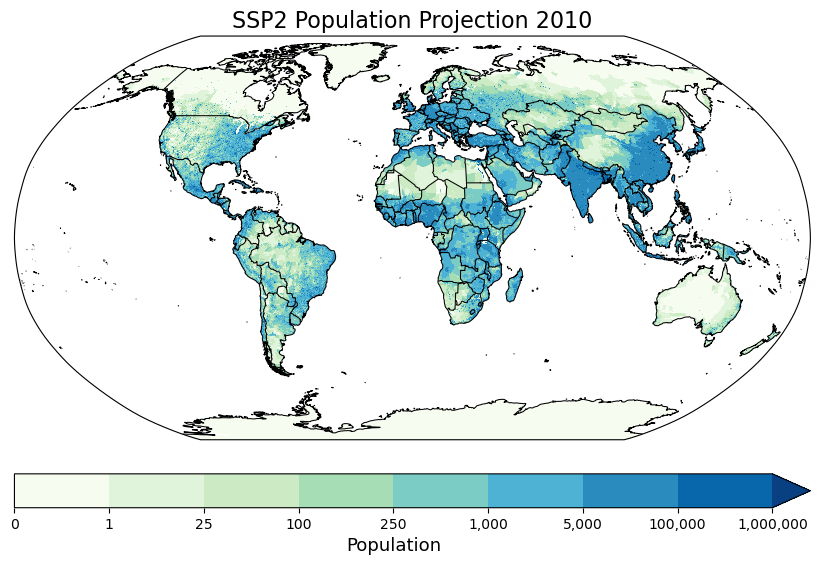

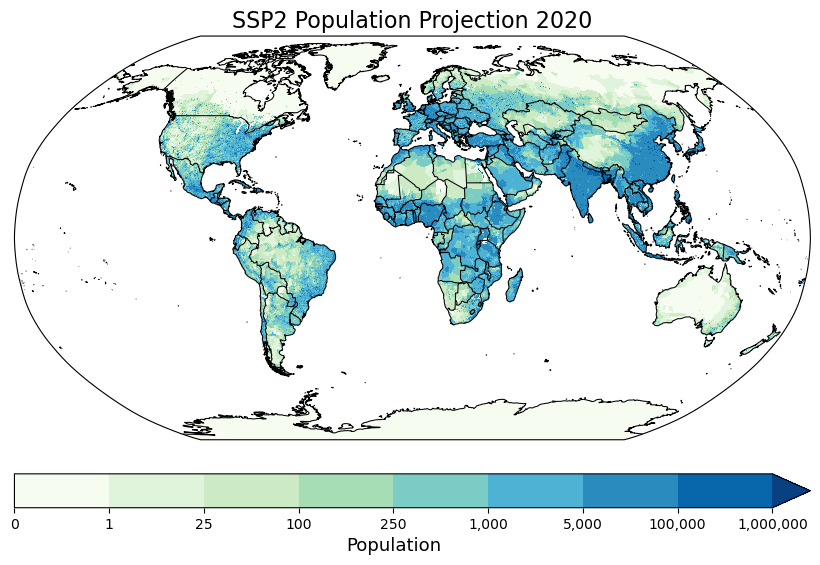

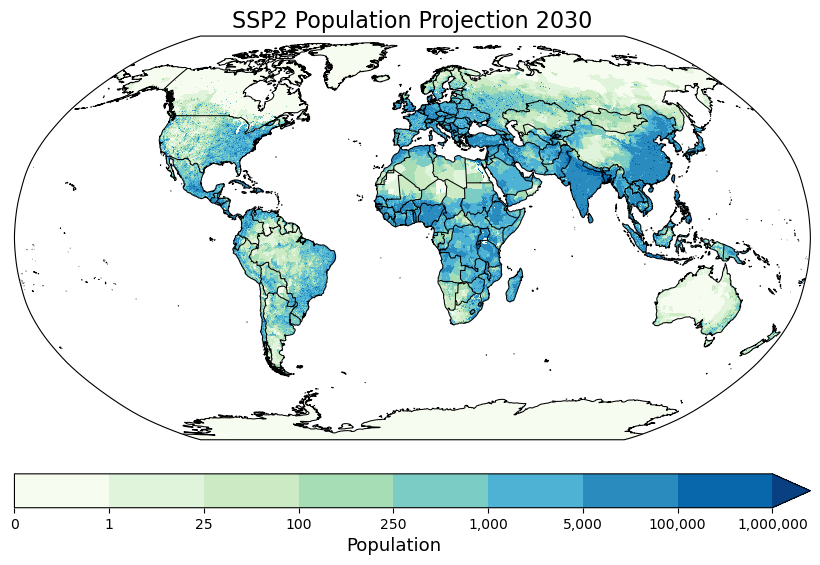

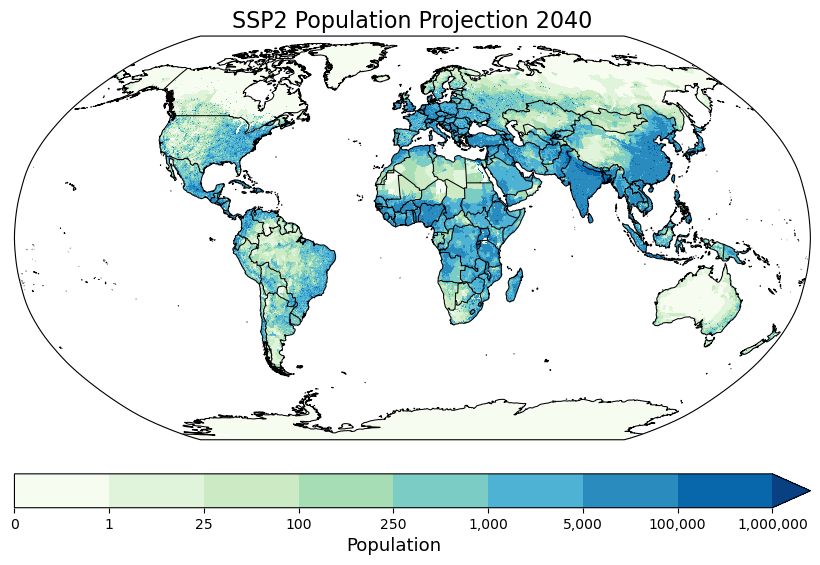

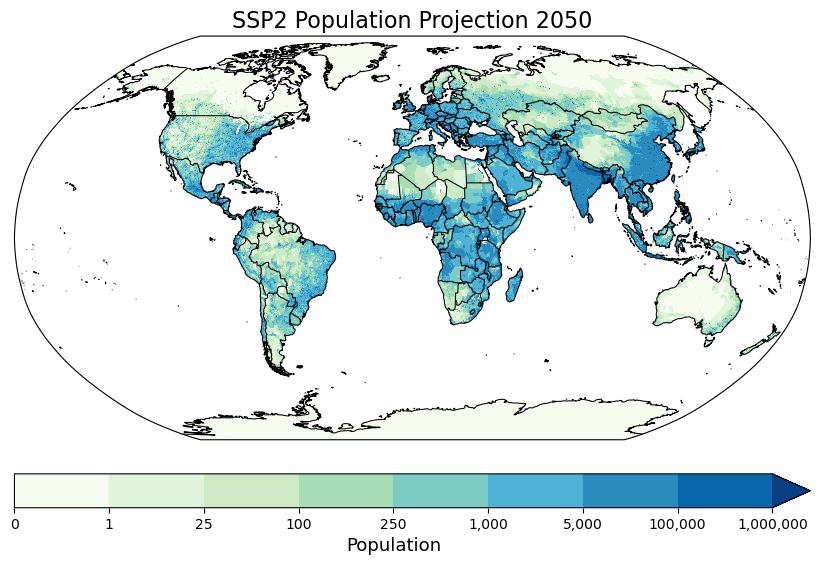

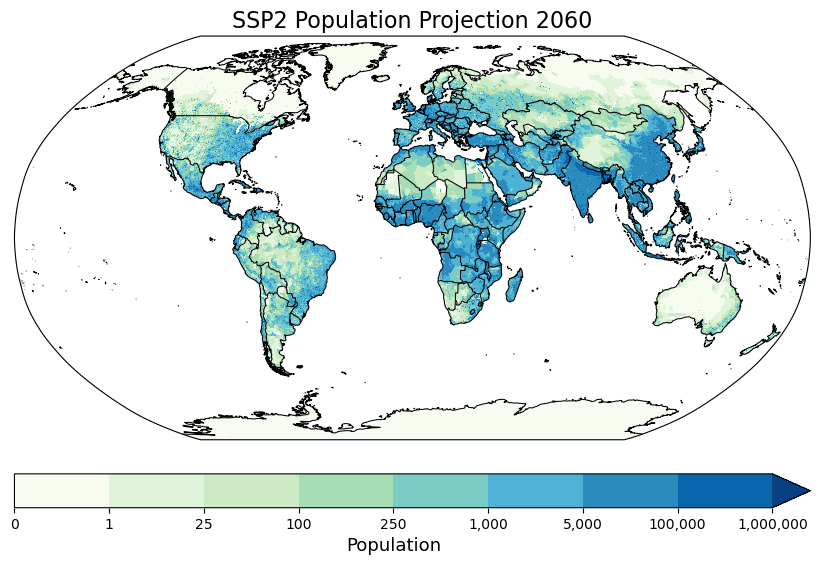

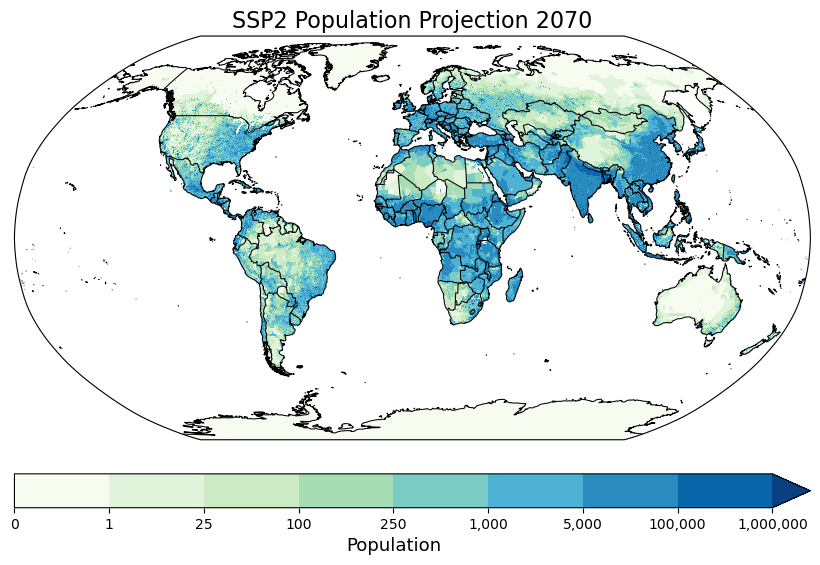

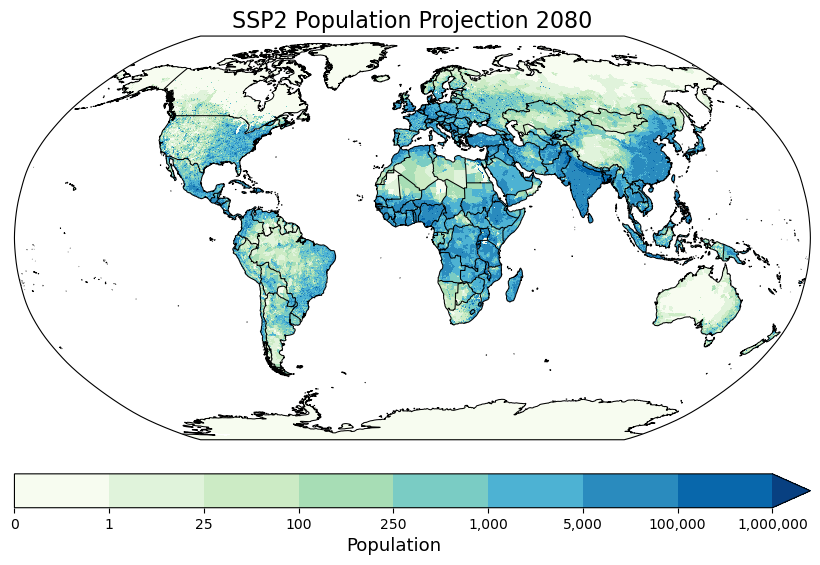

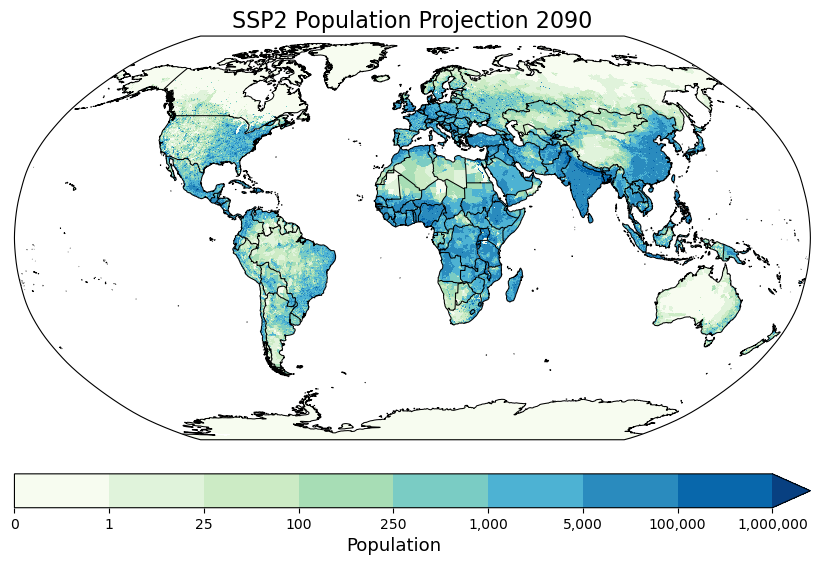

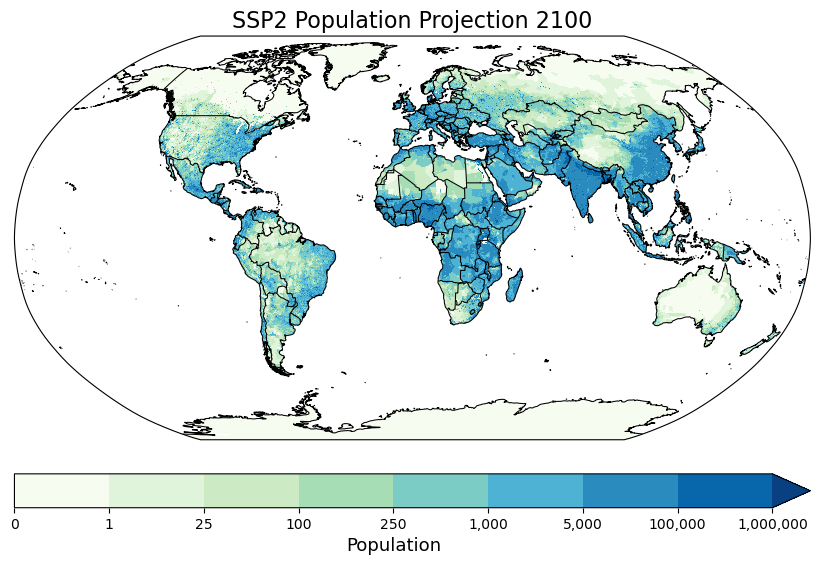

In [8]:
# === Main loop ===
years = range(2000, 2101, 10)

for year in years:
    pop_file = f"ssp2_coarse_grid_{year}.nc"
    pop_path = os.path.join(POP_DIR, pop_file)
    pop = xr.open_dataarray(pop_path)

    pop_land = land_filter(pop)

    plot_population(pop_land, year)